# Session 1: Data Analysis & Basic Model

## Learning Objectives

In this session, we will:

1. **Load and explore financial data** - Understand the structure, quality, and characteristics of our dataset
2. **Perform exploratory data analysis (EDA)** - Identify patterns, outliers, missing data, and relationships
3. **Build a simple linear regression model** - Predict returns using features
4. **Implement a basic trading strategy** - Convert predictions into buy/sell signals
5. **Backtest the strategy** - Evaluate performance using both ML metrics (RMSE, R²) and financial metrics (Sharpe ratio, drawdown)
6. **Identify data leakage** - Understand one of the most common pitfalls in financial ML

## The Problem

We want to build a **systematic trading strategy** that:
- Uses machine learning to predict future returns
- Makes trading decisions **without any arbitrary rules** (pure model-based)
- Can be backtested and evaluated objectively

The key question: **Can we predict $r_{t+1}$ (return from time $t$ to $t+1$) using features observed at time $t$?**

$$r_{t+1} = \frac{P_{t+1} - P_t}{P_t}$$

Where $P_t$ is the price at time $t$.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Import our modules - add parent directory to path
sys.path.insert(0, str(Path("..").resolve()))

from eda.analysis import basic_summary
from features.engineering import prepare_features, prepare_target
from backtesting.engine import backtest_strategy, print_backtest_metrics


In [2]:
# Load data
data_path = Path("../data/saved/stock_a.csv")
df = pd.read_csv(data_path, parse_dates=["timestamp"])

print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Data loaded: 10000 rows, 8 columns


,timestamp,X1,X2,X3,price,bid,ask,returns
0,2020-01-01,NaN,-9.554574,-0.177239,100.00,99.95,100.05,-0.010538
1,2020-01-02,-3.193259,-4.991605,0.820378,98.95,98.90,99.00,-0.003323
2,2020-01-03,-5.326122,-3.871662,2.657185,98.62,98.57,98.67,-0.004748
3,2020-01-06,2.627210,1.327929,4.689063,98.15,98.10,98.20,0.000031
4,2020-01-07,11.737632,3.630729,2.777931,98.15,98.10,98.20,0.012481


In [18]:
df

,timestamp,X1,X2,X3,price,bid,ask,returns
0,2020-01-01,NaN,-9.554574,-0.177239,100.00,99.95,100.05,-0.010538
1,2020-01-02,-3.193259,-4.991605,0.820378,98.95,98.90,99.00,-0.003323
2,2020-01-03,-5.326122,-3.871662,2.657185,98.62,98.57,98.67,-0.004748
3,2020-01-06,2.627210,1.327929,4.689063,98.15,98.10,98.20,0.000031
4,2020-01-07,11.737632,3.630729,2.777931,98.15,98.10,98.20,0.012481
...,...,...,...,...,...,...,...,...
9995,2058-04-24,5.179375,5.020967,-2.048770,59.41,59.38,59.44,0.004781
9996,2058-04-25,11.775321,2.769774,-3.322056,59.69,59.66,59.72,0.012283
9997,2058-04-26,3.078223,2.581138,0.923115,60.42,60.39,60.45,0.005578
9998,2058-04-29,17.631063,2.180761,-6.280703,60.76,60.73,60.79,0.016241


### Question 1.1: Data Structure

**What columns do we have? What does each represent?**


In [3]:
# Basic summary
basic_summary(df)


### Question 1.2: Missing Data

**How much missing data do we have? In which columns?**


**Important:** We should NOT have missing data in `returns` or `price` - these are critical for our analysis.


In [13]:
# Visualize missing data
missing_data = df.isnull().mean() * 100
print("\nMissing Data Percentage:")
print(missing_data) 
# TODO plot or calculate the proportion of missing data
proprotion_missing = missing_data.mean()
print(f"\nProportion of missing data: {proprotion_missing:.2f}%")





Missing Data Percentage:
timestamp    0.00
X1           4.77
X2           5.00
X3           4.87
price        0.00
bid          0.00
ask          0.00
returns      0.00
dtype: float64

Proportion of missing data: 1.83%


### 2.1 Price and Returns Analysis


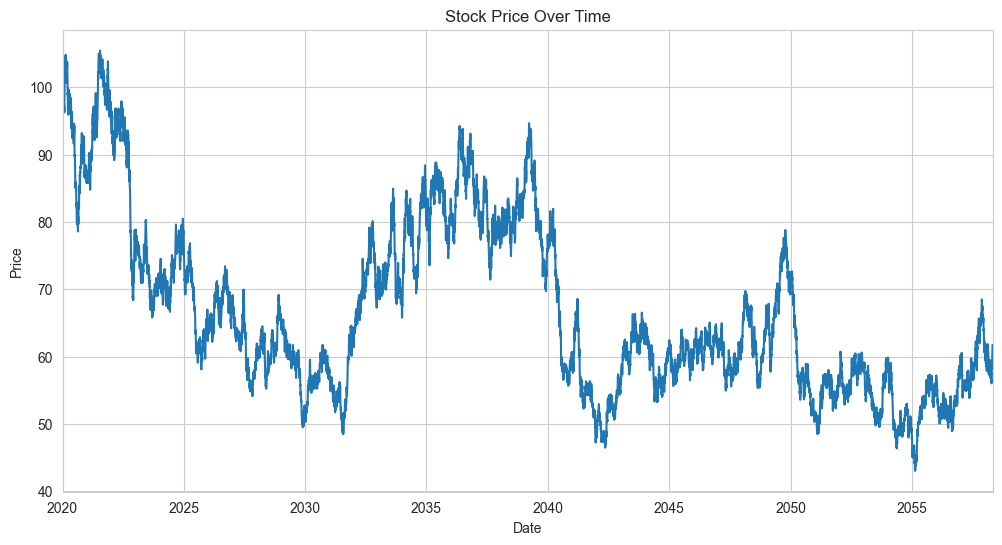

In [14]:
# Plot price series
price_series = df.set_index("timestamp")["price"]
price_series.plot(title="Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()  
# TODO plot prices and returns Series


### Question 2.1: Returns Distribution

**What does the distribution of returns look like? Is it normal?**


Let's check our synthetic data:


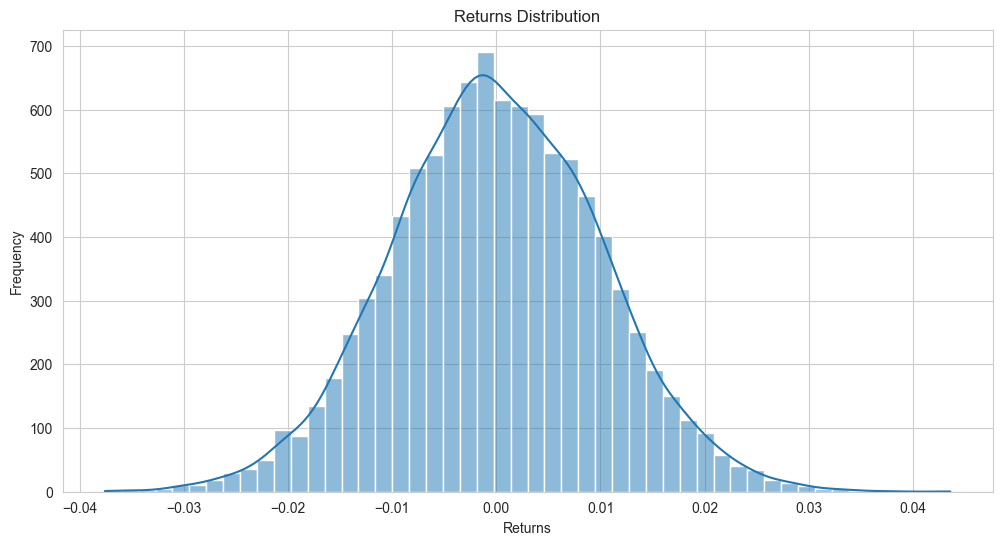

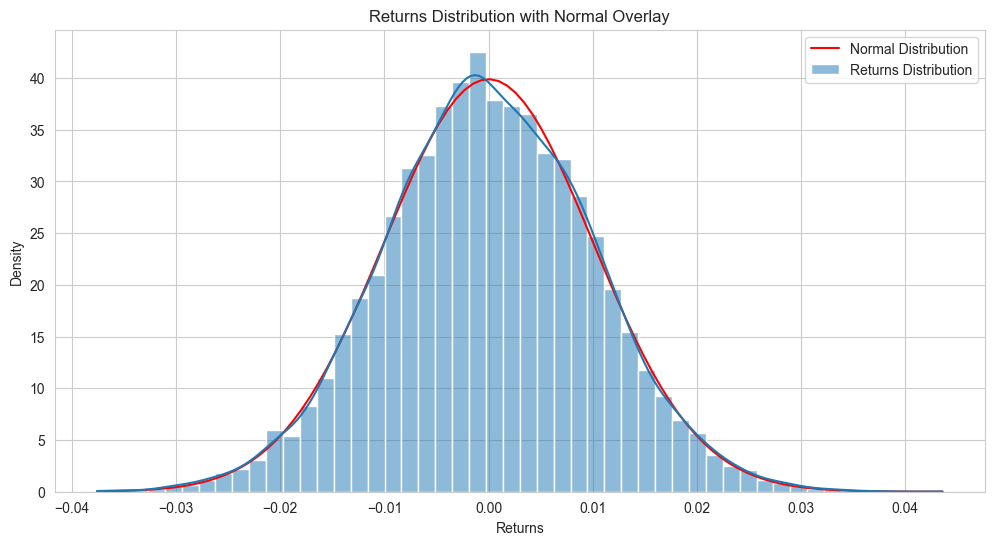

In [19]:
# Returns distribution
returns = df["returns"].dropna()
# Plot returns distributions and show some statistics around it
sns.histplot(returns, bins=50, kde=True)
plt.title("Returns Distribution")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.show()
returns.describe()
#plotting normal gaussian distribution with same mean and std as returns
from scipy.stats import norm    
x = np.linspace(returns.min(), returns.max(), 100)
pdf = norm.pdf(x, returns.mean(), returns.std())
plt.plot(x, pdf, label="Normal Distribution", color="red")
sns.histplot(returns, bins=50, kde=True, stat="density", label="Returns Distribution")
plt.title("Returns Distribution with Normal Overlay")
plt.xlabel("Returns")
plt.ylabel("Density")
plt.legend()
plt.show()  



### 2.2 Feature Analysis


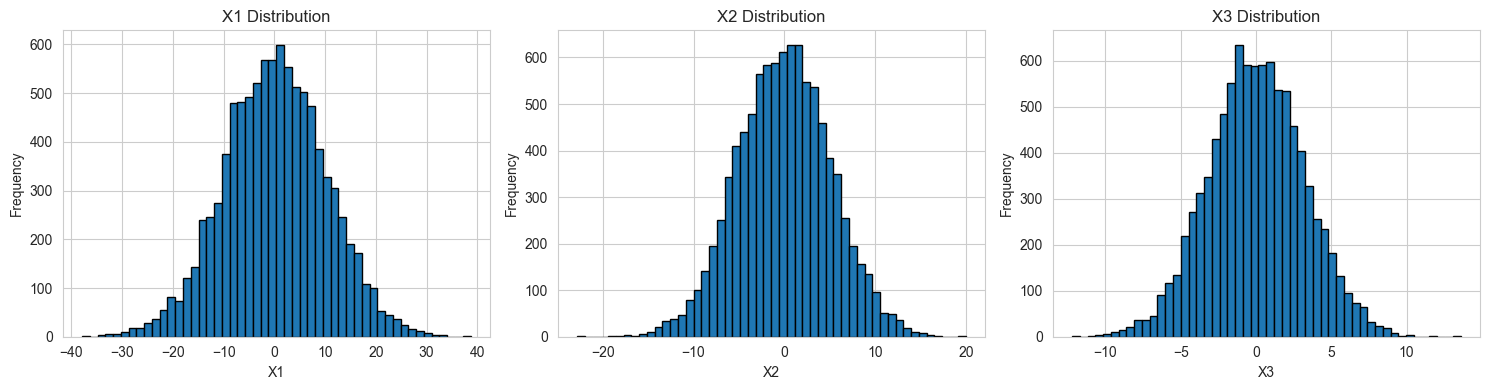

In [7]:
# Feature distributions
feature_cols = ["X1", "X2", "X3"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(feature_cols):
    df[col].hist(bins=50, ax=axes[i], edgecolor="black")
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


### Question 2.2: Feature-Target Relationship

**Do our features have predictive power? Let's check correlations.**



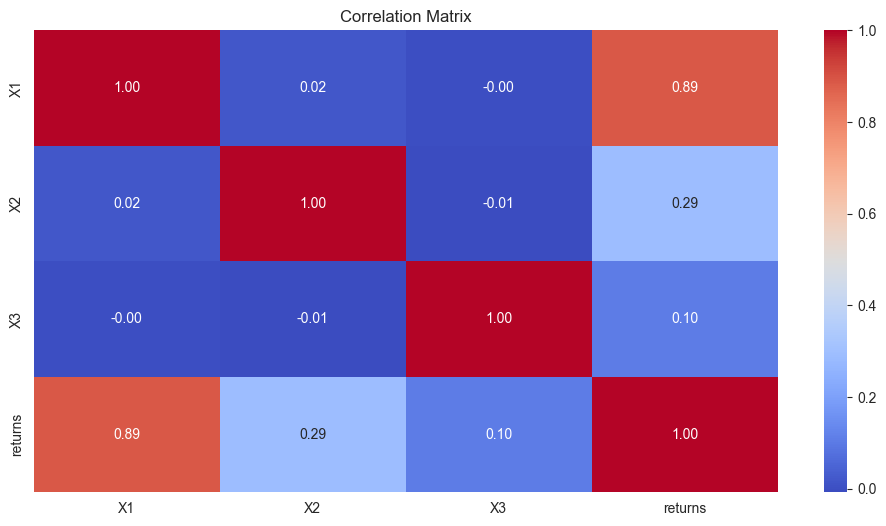

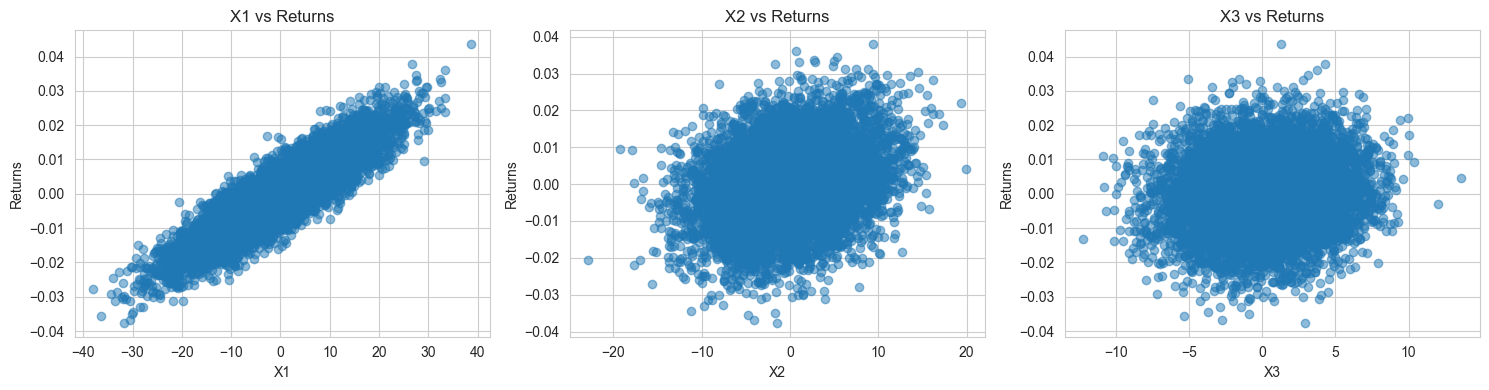

In [ ]:
# Correlation matrix
correlation_matrix = df[feature_cols + ["returns"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()  
# TODO analyze univariate relationships between features and returns
# Scatter plots of features vs returns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df["returns"], alpha=0.5)
    axes[i].set_title(f"{col} vs Returns")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Returns")   
plt.tight_layout()
plt.show()

### 2.3 Note on Automated EDA Tools

**ydata-profiling** (formerly pandas-profiling) is a useful Python package that automatically generates comprehensive HTML reports with detailed statistics, correlations, missing data analysis, and visualizations. It can save significant time during exploratory data analysis.

To use it:
```python
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Data Profile")
profile.to_file("report.html")
```

For this lab, we'll use manual EDA to understand each step, but in practice, automated tools like ydata-profiling can be very helpful for quick data overviews.


## 3. Feature Engineering

For now, feature engineering is minimal - we'll just handle missing values. In future sessions, we'll add:
- Technical indicators (moving averages, RSI, etc.)
- Lagged features
- Rolling statistics
- Feature interactions


In [9]:
# Prepare features and target

# TODO look into the imported functions and fill the todos

X = prepare_features(df, feature_cols=feature_cols)
y = prepare_target(df, target_col="returns")

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nMissing values after processing: {X.isnull().sum().sum()}")

X.head()


Features shape: (10000, 3)
Target shape: (10000,)

Missing values after processing: 1464


,X1,X2,X3
0,NaN,-9.554574,-0.177239
1,-3.193259,-4.991605,0.820378
2,-5.326122,-3.871662,2.657185
3,2.627210,1.327929,4.689063
4,11.737632,3.630729,2.777931


## 4. Train-Test Split

**Critical for time series:** We must use a **chronological split**, not random!

Why? In real trading, we can't use future data to predict the past. Random splits would give us unrealistic performance.


In [10]:
# Chronological split: 80% train, 20% test

# TODO split X, y and df with a chronological 80-20% split

X_train =
X_test = 
y_train =
y_test =

print(f"Train set: {len(X_train)} samples ({X_train.index[0]} to {X_train.index[-1]})")
print(f"Test set: {len(X_test)} samples ({X_test.index[0]} to {X_test.index[-1]})")

# Also split the full dataframe for backtesting
df_train = 
df_test = 


SyntaxError: invalid syntax (681839481.py, line 5)

## 5. Linear Regression Model

We'll start with the simplest model: **Linear Regression**

$$\hat{r}_{t+1} = \beta_0 + \beta_1 X_{1,t} + \beta_2 X_{2,t} + \beta_3 X_{3,t} + \epsilon_t$$

Where $\hat{r}_{t+1}$ is the predicted return.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Model coefficients
print("Model Coefficients:")
for i, col in enumerate(X.columns):
    print(f"  {col}: {model.coef_[i]:.6f}")
print(f"  Intercept: {model.intercept_:.6f}")


### 5.1 Model Evaluation (ML Metrics)


In [25]:
# Calculate ML metrics
train_rmse = 
test_rmse = 
train_mae =
test_mae = 
train_r2 =
test_r2 = 

print("=" * 80)
print("MODEL PERFORMANCE (ML METRICS)")
print("=" * 80)
print(f"\nTrain Set:")
print(f"  RMSE: {train_rmse:.6f}")
print(f"  MAE: {train_mae:.6f}")
print(f"  R²: {train_r2:.4f}")
print(f"\nTest Set:")
print(f"  RMSE: {test_rmse:.6f}")
print(f"  MAE: {test_mae:.6f}")
print(f"  R²: {test_r2:.4f}")
print("=" * 80)


SyntaxError: invalid syntax (1627166686.py, line 2)

### Question 5.1: Model Interpretation

**What do these metrics tell us?**



In [ ]:
# Visualize predictions vs actual

# TODO implement visualization of predicted returns vs actual returns



## 6. Trading Strategy Implementation

**Simple strategy:**
- If predicted return > 0: **BUY** (go long)
- If predicted return < 0: **SELL** (go short)

**Assumptions (for now):**
- We can trade at the **close price** (we'll relax this later)
- Transaction costs: 0.1% per trade
- We can go both long and short


In [ ]:
# Add predictions to test dataframe
df_test["prediction"] = y_test_pred

# Simple strategy: buy if prediction > 0, sell if prediction < 0
df_test["signal"] = np.where(df_test["prediction"] > 0, 1, -1)

print("Signal distribution:")
print(df_test["signal"].value_counts())
print(f"\n% Long: {(df_test['signal'] == 1).sum() / len(df_test) * 100:.2f}%")
print(f"% Short: {(df_test['signal'] == -1).sum() / len(df_test) * 100:.2f}%")


## 7. Backtesting

Now let's see if our strategy is actually profitable!


In [ ]:
# Run backtest
results = backtest_strategy(
    df_test,
    y_test_pred,
    initial_capital=100000,
    transaction_cost=0.001,  # 0.1%
    trade_at="close"
)

# Print metrics
print_backtest_metrics(results)


### Question 7.1: Interpreting Backtest Results

**What do these metrics mean?**


In [ ]:
# Plot equity curve

# TODO plot the equity curve



## 8. Exercise: Find the Data Leakage Bug!

**Challenge:** There's a subtle data leakage issue in our current setup. Can you find it?

**Hint:** Think about when we observe features vs when we can actually trade.


**Challenge:** Re-run the same analysis with `stock_b` that has been generated with little auto-correlation in returns. Do you see a difference? How can you explain it?

**Hint:** Now we have little but real explanatory power on the returns at $t+2$


## Summary

In this session, we:

1. ✅ Loaded and explored financial data
2. ✅ Performed EDA to understand data characteristics
3. ✅ Built a linear regression model to predict returns
4. ✅ Implemented a simple trading strategy
5. ✅ Backtested the strategy with both ML and financial metrics
6. ✅ Identified a data leakage issue (latency between observation and execution)

**Key Takeaways:**
- Good ML metrics ≠ Profitable trading
- Chronological train-test split is essential
- Transaction costs matter!
- Latency/execution timing is critical

**Next Session:** We'll explore logistic regression for direction prediction, threshold tuning, and more sophisticated backtesting.
